# импорты

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
# imports
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, Dataset
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights
from collections import Counter
from tqdm import tqdm
import sklearn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

In [33]:
# constants
DATASET_PATH = '/content/drive/MyDrive/blood_cells_dataset/bloodcells_dataset'
KEEP_CLASSES = ['basophil', 'eosinophil', 'lymphocyte', 'monocyte', 'neutrophil']
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 5
NUM_CLASSES = 5

In [4]:
# augmentation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1,contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# dataset
class CustomLeukocyteDataset(Dataset):
    def __init__(self, subset, transform, label_mapping):
        self.subset = subset
        self.transform = transform
        self.label_mapping = label_mapping

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        y = self.label_mapping[y]
        return x, y

In [6]:
# imagefolder
full_dataset = datasets.ImageFolder(DATASET_PATH)

keep_indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in KEEP_CLASSES
]

In [7]:
# делим кол-во данных на обучение-валидацию-тест
all_names = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in keep_indices]
class_counts = Counter(all_names)
print(class_counts)

np.random.seed(42)
shuffled_indices = np.random.permutation(keep_indices)

total = len(keep_indices)
train_size = int(0.7 * total)
val_size   = int(0.2 * total)
test_size  = total - train_size - val_size

train_indices = shuffled_indices[:train_size]
val_indices   = shuffled_indices[train_size:train_size + val_size]
test_indices  = shuffled_indices[train_size + val_size:]

Counter({'neutrophil': 3329, 'eosinophil': 3117, 'monocyte': 1420, 'basophil': 1218, 'lymphocyte': 1214})


In [8]:
train_classes = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in train_indices]
print("⚖️ Баланс в Train (70%):", Counter(train_classes))

val_classes = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in val_indices]
print("⚖️ Баланс в Val (20%):  ", Counter(val_classes))

test_classes = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in test_indices]
print("⚖️ Баланс в Test (10%): ", Counter(test_classes))

⚖️ Баланс в Train (70%): Counter({'neutrophil': 2290, 'eosinophil': 2215, 'monocyte': 985, 'basophil': 870, 'lymphocyte': 848})
⚖️ Баланс в Val (20%):   Counter({'neutrophil': 705, 'eosinophil': 605, 'monocyte': 279, 'lymphocyte': 240, 'basophil': 230})
⚖️ Баланс в Test (10%):  Counter({'neutrophil': 334, 'eosinophil': 297, 'monocyte': 156, 'lymphocyte': 126, 'basophil': 118})


In [18]:
# назначаем правильные номера для классов
label_mapping={}
for new_idx, class_name in enumerate(KEEP_CLASSES):
  old_idx=full_dataset.class_to_idx[class_name]
  label_mapping[old_idx]=new_idx

train_subset=Subset(full_dataset, train_indices)
val_subset=Subset(full_dataset, val_indices)
test_subset=Subset(full_dataset, test_indices)
print(len(train_subset))
print(len(val_subset))
print(len(test_subset))


7208
2059
1031


In [19]:
# dataset train-val-test
train_dataset = CustomLeukocyteDataset(
    subset=train_subset,
    transform=train_transform,
    label_mapping=label_mapping
    )
val_dataset   = CustomLeukocyteDataset(
    subset=val_subset,
    transform=val_transform,
    label_mapping=label_mapping
    )
test_dataset  = CustomLeukocyteDataset(
    subset=test_subset,
    transform=test_transform,
    label_mapping=label_mapping
    )
x, y = train_dataset[0]
print(type(x))
print(x.shape)
print(y)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
2


In [24]:
# dataloader
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels[:10])
print(label_mapping)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([0, 0, 0, 1, 1, 3, 4, 4, 1, 4])
{0: 0, 1: 1, 4: 2, 5: 3, 6: 4}


In [28]:
# resnet18
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
else:
    device = "cpu"

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

model = model.to(device)

print(f"Устройство: {device}")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


Устройство: cuda
Linear(in_features=512, out_features=5, bias=True)


In [29]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Criterion:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x78d754e5bef0>


In [31]:
best_val_loss = float("inf")
best_model_path = "resnet18_leukocytes_best.pth"

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [34]:
for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch 1/5: 100%|██████████| 226/226 [32:04<00:00,  8.51s/it]


Epoch [1/5] | Train Loss: 0.1088 | Train Acc: 0.9667 | Val Loss: 0.0207 | Val Acc: 0.9956 | LR: 0.000100


Epoch 2/5: 100%|██████████| 226/226 [00:56<00:00,  4.00it/s]


Epoch [2/5] | Train Loss: 0.0352 | Train Acc: 0.9899 | Val Loss: 0.0206 | Val Acc: 0.9922 | LR: 0.000100


Epoch 3/5: 100%|██████████| 226/226 [00:56<00:00,  3.99it/s]


Epoch [3/5] | Train Loss: 0.0249 | Train Acc: 0.9922 | Val Loss: 0.0307 | Val Acc: 0.9908 | LR: 0.000100


Epoch 4/5: 100%|██████████| 226/226 [00:57<00:00,  3.90it/s]


Epoch [4/5] | Train Loss: 0.0273 | Train Acc: 0.9922 | Val Loss: 0.0134 | Val Acc: 0.9961 | LR: 0.000100


Epoch 5/5: 100%|██████████| 226/226 [00:57<00:00,  3.95it/s]


Epoch [5/5] | Train Loss: 0.0240 | Train Acc: 0.9922 | Val Loss: 0.0123 | Val Acc: 0.9971 | LR: 0.000100


In [37]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

print("Лучшая модель загружена")

Лучшая модель загружена


In [41]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=KEEP_CLASSES
    )
)

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)

Test Accuracy: 0.9932104752667313

Classification Report:
              precision    recall  f1-score   support

    basophil       0.98      0.99      0.99       118
  eosinophil       1.00      1.00      1.00       297
  lymphocyte       0.98      1.00      0.99       126
    monocyte       0.99      0.97      0.98       156
  neutrophil       1.00      0.99      1.00       334

    accuracy                           0.99      1031
   macro avg       0.99      0.99      0.99      1031
weighted avg       0.99      0.99      0.99      1031


Confusion Matrix:
[[117   0   0   0   1]
 [  0 297   0   0   0]
 [  0   0 126   0   0]
 [  2   0   2 152   0]
 [  0   0   0   2 332]]


<Figure size 800x800 with 0 Axes>

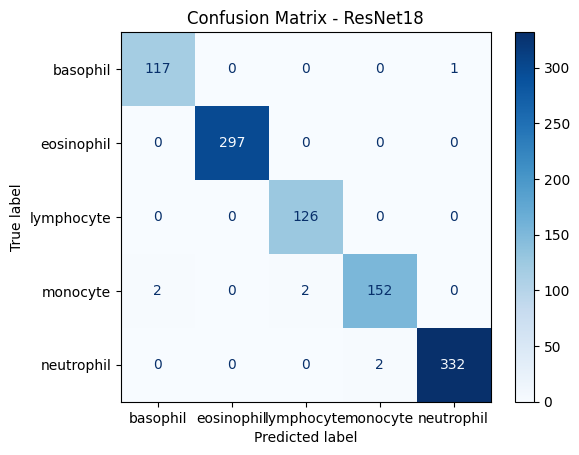

In [43]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=KEEP_CLASSES
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - ResNet18")
plt.show()

In [44]:
misclassified = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):

            if preds[i].cpu() != labels[i]:

                misclassified.append(
                    (
                        images[i].cpu(),
                        labels[i].item(),
                        preds[i].cpu().item()
                    )
                )

print("Количество ошибок:", len(misclassified))

Количество ошибок: 7


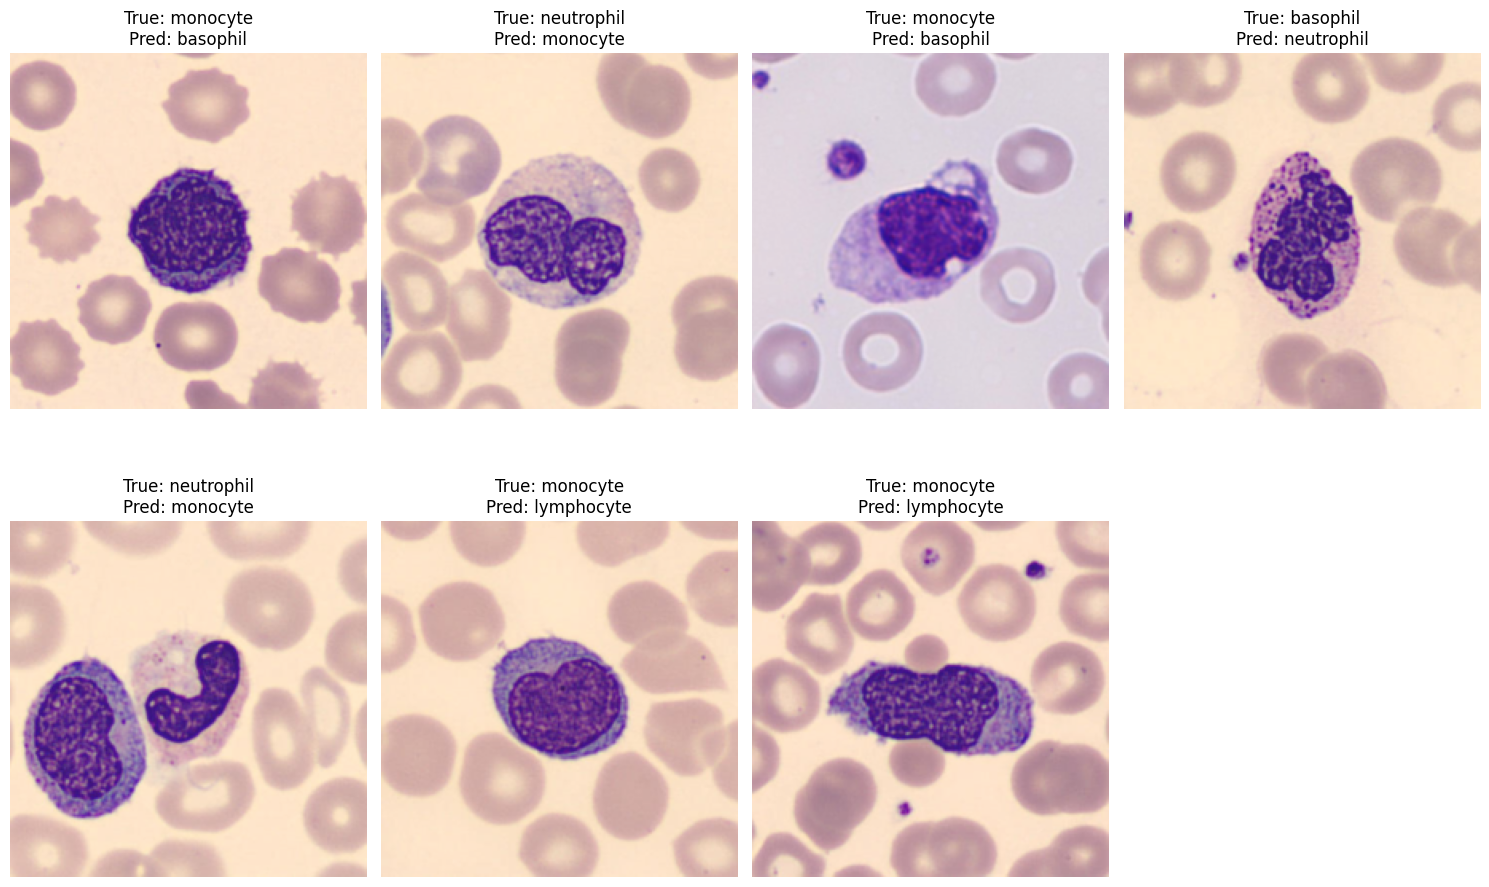

In [45]:
num_show = min(7, len(misclassified))

plt.figure(figsize=(15, 10))

for i in range(num_show):

    image, true_label, pred_label = misclassified[i]

    image = image.permute(1, 2, 0).numpy()

    # денормализация ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {KEEP_CLASSES[true_label]}\nPred: {KEEP_CLASSES[pred_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

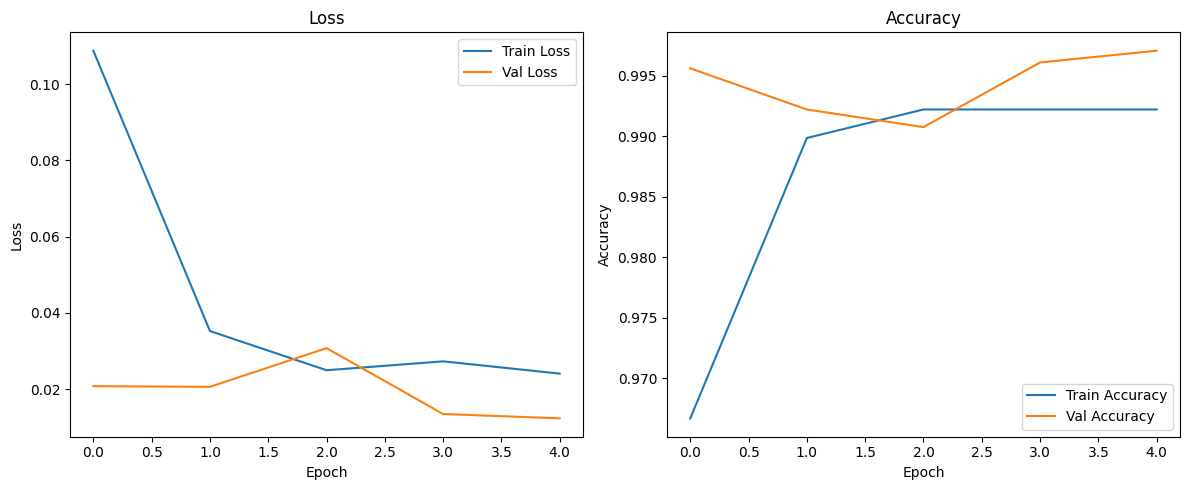

In [46]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()

In [35]:
!nvidia-smi

Thu Jun 18 12:02:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             31W /   70W |    1347MiB /  15360MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----